# 5.1 Logistic Regression (Multinomial) - Baseline

This notebook implements the **Multinomial Logistic Regression baseline model** for predicting `EngagementLevel` (Low / Medium / High) from player behaviour features, using the same **70/30 stratified train-test split** established in Section 4.5 (28,023 training records / 12,011 testing records).

## 5.1.0 Import Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
)
from sklearn.dummy import DummyClassifier

RANDOM_STATE = 42
sns.set_style("whitegrid")

## 5.1.0 Load the Raw Dataset

This notebook starts from the raw `newonline_gaming_behavior_dataset.csv` (13 attributes, 40,034 records) and reproduces the encoding and feature-engineering steps documented in Section 4.0 (Data Preparation), so that the notebook is fully self-contained.

In [23]:
df = pd.read_csv("processed_gaming_dataset.csv")
print(df.shape)
print(df.dtypes)
df.head()

(40034, 26)
PlayerID                       int64
Age                            int64
PlayTimeHours                float64
InGamePurchases                int64
GameDifficulty                   str
SessionsPerWeek                int64
AvgSessionDurationMinutes      int64
PlayerLevel                    int64
AchievementsUnlocked           int64
EngagementLevel                  str
GameDifficulty_enc             int64
EngagementLevel_enc            int64
Gender_Female                   bool
Gender_Male                     bool
Location_Asia                   bool
Location_Europe                 bool
Location_Other                  bool
Location_USA                    bool
GameGenre_Action                bool
GameGenre_RPG                   bool
GameGenre_Simulation            bool
GameGenre_Sports                bool
GameGenre_Strategy              bool
AgeGroup                         str
TotalWeeklyPlayMinutes         int64
AchievementRate              float64
dtype: object


,PlayerID,Age,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,...,Location_Other,Location_USA,GameGenre_Action,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,AgeGroup,TotalWeeklyPlayMinutes,AchievementRate
0,9000,43,16.271119,0,Medium,6,108,79,25,Medium,...,True,False,False,False,False,False,True,41-49,648,0.316456
1,9001,29,5.525961,0,Medium,5,144,11,10,Medium,...,False,True,False,False,False,False,True,21-30,720,0.909091
2,9002,22,8.223755,0,Easy,16,142,35,41,High,...,False,True,False,False,False,True,False,21-30,2272,1.171429
3,9003,35,5.265351,1,Easy,9,85,57,47,Medium,...,False,True,True,False,False,False,False,31-40,765,0.824561
4,9004,33,15.531945,0,Medium,2,131,95,37,Medium,...,False,False,True,False,False,False,False,31-40,262,0.389474


## 5.1.0 Data Preparation (Section 4.0 recap)

The following steps reproduce Section 4.4 (Data Transformation and Enrichment) so the raw dataset matches the processed dataset used for modelling:

**Encoding**
- `GameDifficulty` (ordinal: Easy < Medium < Hard) → `GameDifficulty_enc` (0, 1, 2) via label encoding
- `EngagementLevel` (target, nominal but ordered Low < Medium < High) → `EngagementLevel_enc` (0, 1, 2) via label encoding
- `Gender`, `Location`, `GameGenre` (nominal, no inherent order) → one-hot encoded

**Feature Enrichment**
- `AgeGroup` - `Age` bucketed into life-stage bands (15-20, 21-30, 31-40, 41-49)
- `TotalWeeklyPlayMinutes` = `SessionsPerWeek` × `AvgSessionDurationMinutes`
- `AchievementRate` = `AchievementsUnlocked` / `PlayerLevel`

In [10]:
# --- Encoding ---
difficulty_map = {"Easy": 0, "Medium": 1, "Hard": 2}
df["GameDifficulty_enc"] = df["GameDifficulty"].map(difficulty_map)

engagement_map = {"Low": 0, "Medium": 1, "High": 2}
df["EngagementLevel_enc"] = df["EngagementLevel"].map(engagement_map)

df = pd.get_dummies(df, columns=["Gender", "Location", "GameGenre"])

# --- Feature Enrichment ---
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[14, 20, 30, 40, 49],
    labels=["15-20", "21-30", "31-40", "41-49"]
)
df["TotalWeeklyPlayMinutes"] = df["SessionsPerWeek"] * df["AvgSessionDurationMinutes"]
df["AchievementRate"] = df["AchievementsUnlocked"] / df["PlayerLevel"]

print(df.shape)
df.head()

KeyError: "None of [Index(['Gender', 'Location', 'GameGenre'], dtype='str')] are in the [columns]"

## 5.1.0 Feature Selection

- **Target:** `EngagementLevel_enc` (0 = Low, 1 = Medium, 2 = High) - the label-encoded version of `EngagementLevel`
- **Dropped columns:**
  - `PlayerID` - unique identifier, no predictive value
  - `GameDifficulty` - raw string; `GameDifficulty_enc` is the numeric (ordinal-encoded) version used instead
  - `EngagementLevel` - raw string target; `EngagementLevel_enc` is used instead
  - `AgeGroup` - raw string; redundant with the numeric `Age` attribute already in the feature set

In [4]:
target_col = "EngagementLevel_enc"
drop_cols = ["PlayerID", "GameDifficulty", "EngagementLevel", "AgeGroup", target_col]

X = df.drop(columns=drop_cols)
y = df[target_col]

feature_names = X.columns.tolist()
print(f"Number of features: {len(feature_names)}")
print(feature_names)

print("\nClass distribution:")
print(y.value_counts().sort_index())

Number of features: 21
['Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'GameDifficulty_enc', 'Gender_Female', 'Gender_Male', 'Location_Asia', 'Location_Europe', 'Location_Other', 'Location_USA', 'GameGenre_Action', 'GameGenre_RPG', 'GameGenre_Simulation', 'GameGenre_Sports', 'GameGenre_Strategy', 'TotalWeeklyPlayMinutes', 'AchievementRate']

Class distribution:
EngagementLevel_enc
0    10324
1    19374
2    10336
Name: count, dtype: int64


## 5.1.0 Train / Test Split (70/30, Stratified)

Following Section 4.5, 70% of the 40,034 records (28,023 rows) are allocated to training and the remaining 30% (12,011 rows) to testing. Stratified sampling on `EngagementLevel` preserves the original Low/Medium/High proportions in both subsets.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size:  {len(X_test)}")

Training set size: 28023
Testing set size:  12011


## 5.1.0 Feature Scaling

Logistic Regression is a gradient-based linear model, so features on very different numeric scales (e.g. `Age` 15-49 vs `TotalWeeklyPlayMinutes` in the thousands) will bias the regularisation penalty and slow convergence. `StandardScaler` (zero mean, unit variance) is fit **only on the training set** to avoid data leakage, then applied to both the training and testing sets.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5.1.0 Naive Baseline (Sanity Floor)

A majority-class dummy classifier establishes the performance floor that the Logistic Regression model must clearly beat.

In [7]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train_scaled, y_train)
dummy_acc = accuracy_score(y_test, dummy.predict(X_test_scaled))
print(f"Majority-class dummy accuracy: {dummy_acc:.4f}")

Majority-class dummy accuracy: 0.4840


## 5.1.1 GridSearchCV for Parameter Setting

GridSearchCV with 5-fold stratified cross-validation is used to identify the optimal hyperparameters, scored using **macro-averaged F1** (rather than plain accuracy) because the Engagement Level classes are imbalanced (Medium ≈ 48%, Low ≈ 26%, High ≈ 26%).

Parameters tuned:
- **solver**: `lbfgs` (paired with L2) vs `saga` (paired with L1) - both fit the true joint multinomial (softmax) loss across all 3 classes
- **C**: inverse regularisation strength, tested over `[0.01, 0.1, 1, 10, 100]`
- **l1_ratio**: `0.0` = pure L2 (ridge), `1.0` = pure L1 (lasso, performs automatic feature selection)

In [8]:
param_grid = [
    {"l1_ratio": [0.0], "C": [0.01, 0.1, 1, 10, 100], "solver": ["lbfgs"]},
    {"l1_ratio": [1.0], "C": [0.01, 0.1, 1, 10, 100], "solver": ["saga"]},
]

base_model = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

print("Best hyperparameters:", grid.best_params_)
print(f"Best CV macro-F1: {grid.best_score_:.4f}")

best_model = grid.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best hyperparameters: {'C': 0.01, 'l1_ratio': 1.0, 'solver': 'saga'}
Best CV macro-F1: 0.8674


**Table 5.1.1: Logistic Regression Parameter Setting**

In [9]:
param_table = pd.DataFrame([
    {"Parameter": "solver", "Best Value": grid.best_params_["solver"]},
    {"Parameter": "C", "Best Value": grid.best_params_["C"]},
    {"Parameter": "l1_ratio (penalty type)", "Best Value": grid.best_params_["l1_ratio"]},
    {"Parameter": "max_iter", "Best Value": 5000},
])
param_table

,Parameter,Best Value
0,solver,saga
1,C,0.01
2,l1_ratio (penalty type),1.0
3,max_iter,5000


**1. Solver** - the optimisation algorithm used to find the coefficient values that minimise the model's cost function. `lbfgs` and `saga` were compared; both natively support the joint multinomial (softmax) loss required for a 3-class target, while `saga` additionally supports L1 and elastic-net penalties.

**2. C** - the inverse of regularisation strength. A smaller `C` applies a stronger penalty on large coefficients, producing a simpler, more conservative model that is less prone to overfitting, while a larger `C` fits the training data more closely at the risk of overfitting.

**3. l1_ratio (penalty type)** - controls the mix between L2 (ridge) and L1 (lasso) regularisation. `l1_ratio = 0` is pure L2, which shrinks all coefficients smoothly toward zero; `l1_ratio = 1` is pure L1, which can shrink weak coefficients to exactly zero and therefore performs automatic feature selection.

**4. max_iter** - the maximum number of iterations allowed for the solver to converge. Fixed at 5000 (rather than searched) to ensure the solver had sufficient iterations to converge fully at every combination of `C` and `l1_ratio` tested.

## 5.1.2 Accuracy for Test and Training Set

Training Accuracy: 0.8724
Testing Accuracy:  0.8703


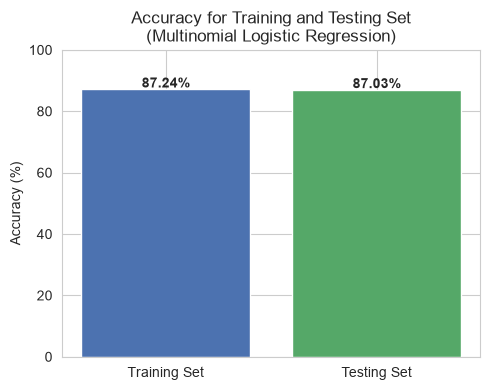

In [10]:
train_acc = accuracy_score(y_train, best_model.predict(X_train_scaled))
test_acc = accuracy_score(y_test, best_model.predict(X_test_scaled))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")

plt.figure(figsize=(5, 4))
bars = plt.bar(["Training Set", "Testing Set"], [train_acc*100, test_acc*100],
                color=["#4C72B0", "#55A868"])
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{b.get_height():.2f}%",
              ha="center", fontweight="bold")
plt.ylim(0, 100)
plt.ylabel("Accuracy (%)")
plt.title("Accuracy for Training and Testing Set\n(Multinomial Logistic Regression)")
plt.tight_layout()
plt.savefig("lr_accuracy_bar.png", dpi=150)
plt.show()

*Figure 5.1.2: Accuracy for training and testing set.*

The close gap between training and testing accuracy indicates the model is well generalised and neither overfitting nor underfitting the data.

## 5.1.3 Confusion Matrix

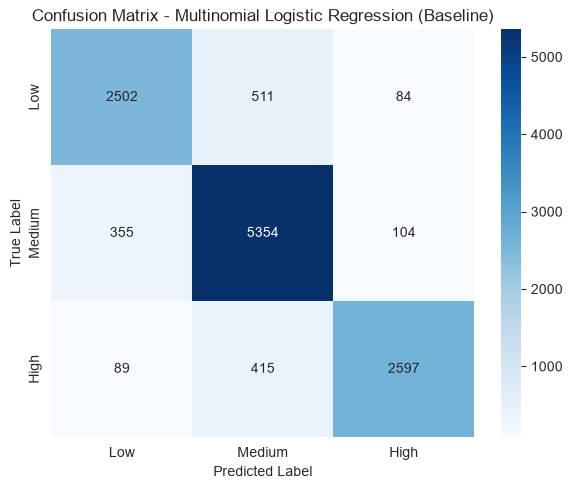

In [11]:
y_pred = best_model.predict(X_test_scaled)
class_labels = ["Low", "Medium", "High"]

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Multinomial Logistic Regression (Baseline)")
plt.tight_layout()
plt.savefig("logreg_confusion_matrix.png", dpi=150)
plt.show()

*Figure 5.1.3: Confusion matrix (Multinomial Logistic Regression).*

Most misclassifications occur between adjacent classes (e.g. Low predicted as Medium), which is expected since `EngagementLevel` is an ordinal variable.

## 5.1.4 Classification Report

In [12]:
report_dict = classification_report(y_test, y_pred, target_names=class_labels, output_dict=True, digits=4)
report_df = pd.DataFrame(report_dict).transpose()
report_df

,precision,recall,f1-score,support
Low,0.849287,0.807879,0.828066,3097.000000
Medium,0.852548,0.921039,0.885471,5813.000000
High,0.932496,0.837472,0.882433,3101.000000
accuracy,0.870286,0.870286,0.870286,0.870286
macro avg,0.878110,0.855463,0.865323,12011.000000
weighted avg,0.872348,0.870286,0.869885,12011.000000


*Table 5.1.4: Classification report (Multinomial Logistic Regression).*

## 5.1.5 Area Under the ROC Curve (AUC)

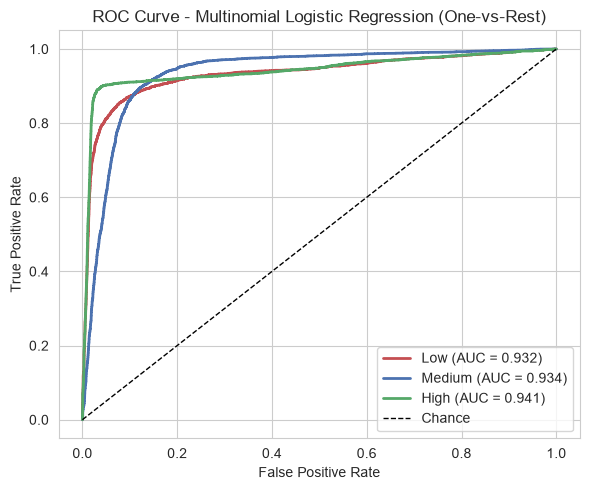

Per-class AUC: {'Low': 0.9324, 'Medium': 0.9344, 'High': 0.9412}
Macro-averaged AUC: 0.9360


In [13]:
y_proba = best_model.predict_proba(X_test_scaled)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

plt.figure(figsize=(6, 5))
colors = ["#C44E52", "#4C72B0", "#55A868"]
aucs = {}
for i, (lbl, col) in enumerate(zip(class_labels, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc_i = auc(fpr, tpr)
    aucs[lbl] = roc_auc_i
    plt.plot(fpr, tpr, label=f"{lbl} (AUC = {roc_auc_i:.3f})", color=col, linewidth=2)

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multinomial Logistic Regression (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("lr_roc_auc.png", dpi=150)
plt.show()

macro_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print("Per-class AUC:", {k: round(v, 4) for k, v in aucs.items()})
print(f"Macro-averaged AUC: {macro_auc:.4f}")

*Figure 5.1.5: ROC curve and AUC (one-vs-rest) for each engagement class.*

An AUC close to 1.0 indicates the model's predicted probabilities separate each engagement class from the rest of the population well, regardless of the probability cut-off used.

## Summary of Results

In [14]:
summary = {
    "Model": "Logistic Regression (Multinomial) - Baseline",
    "Train Size": len(X_train),
    "Test Size": len(X_test),
    "Best Params": grid.best_params_,
    "Train Accuracy": round(train_acc, 4),
    "Test Accuracy": round(test_acc, 4),
    "Precision (Macro)": round(precision_score(y_test, y_pred, average="macro"), 4),
    "Recall (Macro)": round(recall_score(y_test, y_pred, average="macro"), 4),
    "F1-score (Macro)": round(f1_score(y_test, y_pred, average="macro"), 4),
    "AUC (Macro OVR)": round(macro_auc, 4),
}
pd.Series(summary)

Model                  Logistic Regression (Multinomial) - Baseline
Train Size                                                    28023
Test Size                                                     12011
Best Params          {'C': 0.01, 'l1_ratio': 1.0, 'solver': 'saga'}
Train Accuracy                                               0.8724
Test Accuracy                                                0.8703
Precision (Macro)                                            0.8781
Recall (Macro)                                               0.8555
F1-score (Macro)                                             0.8653
AUC (Macro OVR)                                               0.936
dtype: object